# IMPORTS

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import (
    Embedding, Conv1D, GlobalMaxPooling1D, GlobalAveragePooling1D,
    Dense, Dropout, SpatialDropout1D, BatchNormalization, 
    Bidirectional, LSTM, Concatenate, Input , GRU , MaxPooling1D
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.preprocessing import OneHotEncoder

import spacy
import string

warnings.filterwarnings("ignore")

2025-12-15 03:46:34.033981: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765770394.226033      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765770394.279272      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

# HYPERPARAMETERS


In [2]:
vocab_size = 10000
MAX_LEN = 1200
embedding_dim = 100


#  LOAD DATA


In [3]:
df = pd.read_csv("/kaggle/input/nn-26-review-sentiment-classification/train.csv")
df = df.drop('id', axis=1)
df = df.drop_duplicates()

# clean text

In [4]:

def clean_text_column(df, col_name):
    df_clean = df.copy()
    df_clean[col_name] = df_clean[col_name].str.lower()
    
    contractions_dict = {
        "can't": "can not", "won't": "will not", "n't": " not",
        "'re": " are", "'s": " is", "'d": " would",
        "'ll": " will", "'t": " not", "'ve": " have", "'m": " am"
    }
    
    for key, value in contractions_dict.items():
        df_clean[col_name] = df_clean[col_name].str.replace(key, value, regex=False)
            
    df_clean[col_name] = df_clean[col_name].str.replace(r'\n', ' ', regex=True)
    df_clean[col_name] = df_clean[col_name].str.replace(r'([.,!?()])', r' \1 ', regex=True)
    df_clean[col_name] = df_clean[col_name].str.replace('&', ' and ', regex=False)
    df_clean[col_name] = df_clean[col_name].str.replace(r'[\$\(\)\"\/]', '', regex=True)
    df_clean[col_name] = df_clean[col_name].str.replace(r'\s+', ' ', regex=True)
    df_clean[col_name] = df_clean[col_name].str.strip()
    
    return df_clean

df = clean_text_column(df, 'text')

# lemmatzer

In [5]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
nlp.max_length = 2000000

def clean_and_lemmatize(text):
    doc = nlp(text)
    cleaned = []
    for token in doc:
        lemma = token.lemma_.lower()
        if lemma in string.punctuation:
            continue
        if not lemma.isalpha():
            continue
        cleaned.append(lemma)
    return " ".join(cleaned)
df["text"] = df["text"].apply(clean_and_lemmatize)


# 4. SPLIT DATA


In [6]:
X_train, X_val, y_train_raw, y_val_raw = train_test_split(
    df['text'], 
    df['review'], 
    test_size=0.2, 
    random_state=30, 
    stratify=df['review'],  # Stratify using original labels
    shuffle=True
)
print(f"Train set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")

Train set size: 5599
Validation set size: 1400


In [7]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')


y_train = ohe.fit_transform(y_train_raw.values.reshape(-1, 1))
y_val = ohe.transform(y_val_raw.values.reshape(-1, 1))

num_classes = len(ohe.categories_[0])
classes = ohe.categories_[0]

print(f"Number of classes: {num_classes}")
print(f"Classes: {classes}")

Number of classes: 5
Classes: ['Bad' 'Excellent' 'Good' 'Very bad' 'Very good']


# augment
 

In [15]:
def balance_dataset(X, y, target=1000):
    """
    Balance dataset accepting both Pandas Series and NumPy Arrays.
    """
    
    y_integers = np.argmax(y, axis=1) 
    y_series = pd.Series(y_integers, name='label')
       

    df_train = pd.concat([X, y_series], axis=1)
    
    balanced_dfs = []
    for label, group in df_train.groupby(y_series.name):
        current_size = len(group)
        
        if current_size > target:
            sampled = group.sample(n=target, random_state=42)
        else:
            upsample_target = min(target, current_size * 2) # Limit duplication
            sampled = group.sample(n=upsample_target, replace=True, random_state=42)
        
        balanced_dfs.append(sampled)
    
    balanced_df = pd.concat(balanced_dfs, ignore_index=True)
    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    
    return balanced_df[X.name], balanced_df[y_series.name]


In [16]:
X_train_bal, y_train_bal_int = balance_dataset(X_train, y_train, target=1000)
y_train_bal = to_categorical(y_train_bal_int, num_classes=num_classes)

print(f"New X shape: {X_train_bal.shape}")
print(f"New y shape: {y_train_bal.shape}")

New X shape: (4838,)
New y shape: (4838, 5)


#  CALCULATE CLASS WEIGHTS

In [17]:
y_train_int = np.argmax(y_train, axis=1)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

Class weights: {0: 2.1617760617760617, 1: 0.5994646680942184, 2: 1.3672771672771673, 3: 2.6725536992840095, 4: 0.5669873417721519}


In [18]:
y_train_true = np.argmax(y_train, axis=1)
y_val_true = np.argmax(y_val, axis=1)

# embedding

In [19]:
glove_path = '/kaggle/input/glove6b100dtxt/glove.6B.100d.txt'
embeddings_index = {}

with open(glove_path, 'r', encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs


# tokenizer

In [20]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')

In [21]:
vocab_size_actual = min(vocab_size, len(tokenizer.word_index)) + 1
embedding_matrix = np.zeros((vocab_size_actual, embedding_dim))

hits = 0
misses = 0

for word, i in tokenizer.word_index.items():
    if i >= vocab_size_actual:
        continue
    
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))
        misses += 1


# CNN MODEL

In [22]:

inputs = Input(shape=(MAX_LEN,))

embedding_layer = Embedding(
    input_dim=vocab_size_actual,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=False
)(inputs)

x = SpatialDropout1D(0.3)(embedding_layer)



branch_3 = Conv1D(filters=256, kernel_size=3, activation='relu', padding='same')(x)
branch_3 = BatchNormalization()(branch_3)
branch_3 = GlobalMaxPooling1D()(branch_3)

branch_4 = Conv1D(filters=256, kernel_size=4, activation='relu', padding='same')(x)
branch_4 = BatchNormalization()(branch_4)
branch_4 = GlobalMaxPooling1D()(branch_4)

branch_5 = Conv1D(filters=256, kernel_size=5, activation='relu', padding='same')(x)
branch_5 = BatchNormalization()(branch_5)
branch_5 = GlobalMaxPooling1D()(branch_5)


merged = Concatenate()([branch_3, branch_4, branch_5])

x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(merged)
x = Dropout(0.6)(x)

x = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(x)
x = Dropout(0.4)(x)

outputs = Dense(num_classes, activation='softmax')(x)

cnn_model = Model(inputs=inputs, outputs=outputs)


I0000 00:00:1765770789.131276      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765770789.131940      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [23]:
cnn_model.compile(
    optimizer=Adam(learning_rate=0.001), 
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1200)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1200, 100) │  1,000,100 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 1200, 100) │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1200, 256) │     77,056 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1200, 256) │    102,656 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1200, 256) │    128,256 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1200, 256) │      1,024 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1200, 256) │      1,024 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1200, 256) │      1,024 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 768)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     98,432 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 5)         │        325 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,418,153 (5.41 MB)

 Trainable params: 416,517 (1.59 MB)

 Non-trainable params: 1,001,636 (3.82 MB)

In [25]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001, verbose=1)
]

cnn_history = cnn_model.fit(
    X_train_pad, y_train,       
    validation_data=(X_val_pad, y_val), 
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    class_weight=class_weight_dict, 
    verbose=1
)

Epoch 1/50


I0000 00:00:1765770915.774352     154 service.cc:148] XLA service 0x7ad780016d60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765770915.775051     154 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765770915.775072     154 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765770916.268888     154 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/44 ━━━━━━━━━━━━━━━━━━━━ 8:08 11s/step - accuracy: 0.1328 - loss: 26.9366

I0000 00:00:1765770924.084687     154 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 381ms/step - accuracy: 0.2408 - loss: 10.7852 - val_accuracy: 0.3543 - val_loss: 4.2622 - learning_rate: 0.0010
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.3534 - loss: 4.1875 - val_accuracy: 0.3543 - val_loss: 4.0110 - learning_rate: 0.0010
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.3420 - loss: 3.9276 - val_accuracy: 0.3529 - val_loss: 3.8231 - learning_rate: 0.0010
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.3406 - loss: 3.7771 - val_accuracy: 0.3529 - val_loss: 3.6662 - learning_rate: 0.0010
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.3397 - loss: 3.6198 - val_accuracy: 0.3521 - val_loss: 3.5194 - learning_rate: 0.0010
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.2832 - loss: 3.5022 - val_accuracy: 0.1157 - val_loss: 3.3854 - learning_rate: 0.0010
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.2457 - loss: 3.3500 - val_accuracy: 0

#   GRU MODEL


In [26]:
embedding_layer_lstm = Embedding(
    input_dim=vocab_size_actual,
    output_dim=embedding_dim,
    input_length=MAX_LEN,
    weights=[embedding_matrix],
    trainable=True
)

lstm_model = Sequential([
    embedding_layer_lstm,
    SpatialDropout1D(0.3),

    Bidirectional(GRU(128, return_sequences=True)),
  
    Bidirectional(GRU(64, return_sequences=True)),
    
    Bidirectional(GRU(32,return_sequences=False)),

    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    
    
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    
    Dense(num_classes, activation='softmax')
], name='Simplified_BiGRU')


lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


lstm_model.summary()

Model: "Simplified_BiGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     1,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,100 (3.82 MB)

 Trainable params: 1,000,100 (3.82 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
lstm_history = lstm_model.fit(
     X_train_pad, y_train,       
    validation_data=(X_val_pad, y_val), 
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 26s 415ms/step - accuracy: 0.2317 - loss: 3.0869 - val_accuracy: 0.2486 - val_loss: 2.4950 - learning_rate: 0.0010
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 18s 410ms/step - accuracy: 0.2353 - loss: 2.3686 - val_accuracy: 0.2314 - val_loss: 2.0542 - learning_rate: 0.0010
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 18s 402ms/step - accuracy: 0.2397 - loss: 1.9878 - val_accuracy: 0.2471 - val_loss: 1.8247 - learning_rate: 0.0010
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 18s 401ms/step - accuracy: 0.2428 - loss: 1.7575 - val_accuracy: 0.2929 - val_loss: 1.6217 - learning_rate: 0.0010
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 18s 401ms/step - accuracy: 0.3026 - loss: 1.6231 - val_accuracy: 0.3479 - val_loss: 1.4746 - learning_rate: 0.0010
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 18s 404ms/step - accuracy: 0.3676 - loss: 1.4620 - val_accuracy: 0.3836 - val_loss: 1.3703 - learning_rate: 0.0010
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 18s 406ms/step - accuracy: 0.3832 - loss: 1.

# Eval

In [29]:
# CNN Predictions
cnn_train_pred = cnn_model.predict(X_train_pad)
cnn_train_pred_classes = np.argmax(cnn_train_pred, axis=1)

cnn_val_pred = cnn_model.predict(X_val_pad)
cnn_val_pred_classes = np.argmax(cnn_val_pred, axis=1)

# LSTM Predictions
lstm_train_pred = lstm_model.predict(X_train_pad)
lstm_train_pred_classes = np.argmax(lstm_train_pred, axis=1)

lstm_val_pred = lstm_model.predict(X_val_pad)
lstm_val_pred_classes = np.argmax(lstm_val_pred, axis=1)

175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step


In [30]:
print("CNN MODEL - TRAINING SET")
print("="*50)
print(classification_report(y_train_true, cnn_train_pred_classes, target_names=ohe.categories_[0]))

print("CNN MODEL - VALIDATION SET")
print("="*50)
print(classification_report(y_val_true, cnn_val_pred_classes, target_names=ohe.categories_[0]))


CNN MODEL - TRAINING SET
              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00       518
   Excellent       0.00      0.00      0.00      1868
        Good       1.00      0.00      0.00       819
    Very bad       1.00      0.00      0.01       419
   Very good       0.35      1.00      0.52      1975

    accuracy                           0.35      5599
   macro avg       0.47      0.20      0.11      5599
weighted avg       0.35      0.35      0.19      5599

CNN MODEL - VALIDATION SET
              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00       129
   Excellent       0.00      0.00      0.00       467
        Good       0.00      0.00      0.00       205
    Very bad       0.00      0.00      0.00       105
   Very good       0.35      1.00      0.52       494

    accuracy                           0.35      1400
   macro avg       0.07      0.20      0.10      1400
weighted avg       0.12  

In [31]:
print("GRU MODEL - TRAINING SET")
print("="*50)
print(classification_report(y_train_true, lstm_train_pred_classes, target_names=ohe.categories_[0]))

print("GRU MODEL - VALIDATION SET")
print("="*50)
print(classification_report(y_val_true, lstm_val_pred_classes, target_names=ohe.categories_[0]))

GRU MODEL - TRAINING SET
              precision    recall  f1-score   support

         Bad       0.61      0.38      0.47       518
   Excellent       0.47      0.92      0.62      1868
        Good       0.41      0.29      0.34       819
    Very bad       0.75      0.85      0.80       419
   Very good       0.36      0.11      0.17      1975

    accuracy                           0.49      5599
   macro avg       0.52      0.51      0.48      5599
weighted avg       0.46      0.49      0.42      5599

GRU MODEL - VALIDATION SET
              precision    recall  f1-score   support

         Bad       0.38      0.29      0.33       129
   Excellent       0.47      0.87      0.61       467
        Good       0.31      0.22      0.26       205
    Very bad       0.53      0.50      0.51       105
   Very good       0.37      0.14      0.20       494

    accuracy                           0.43      1400
   macro avg       0.41      0.40      0.38      1400
weighted avg       0.41  

#  VISUALIZATIONS

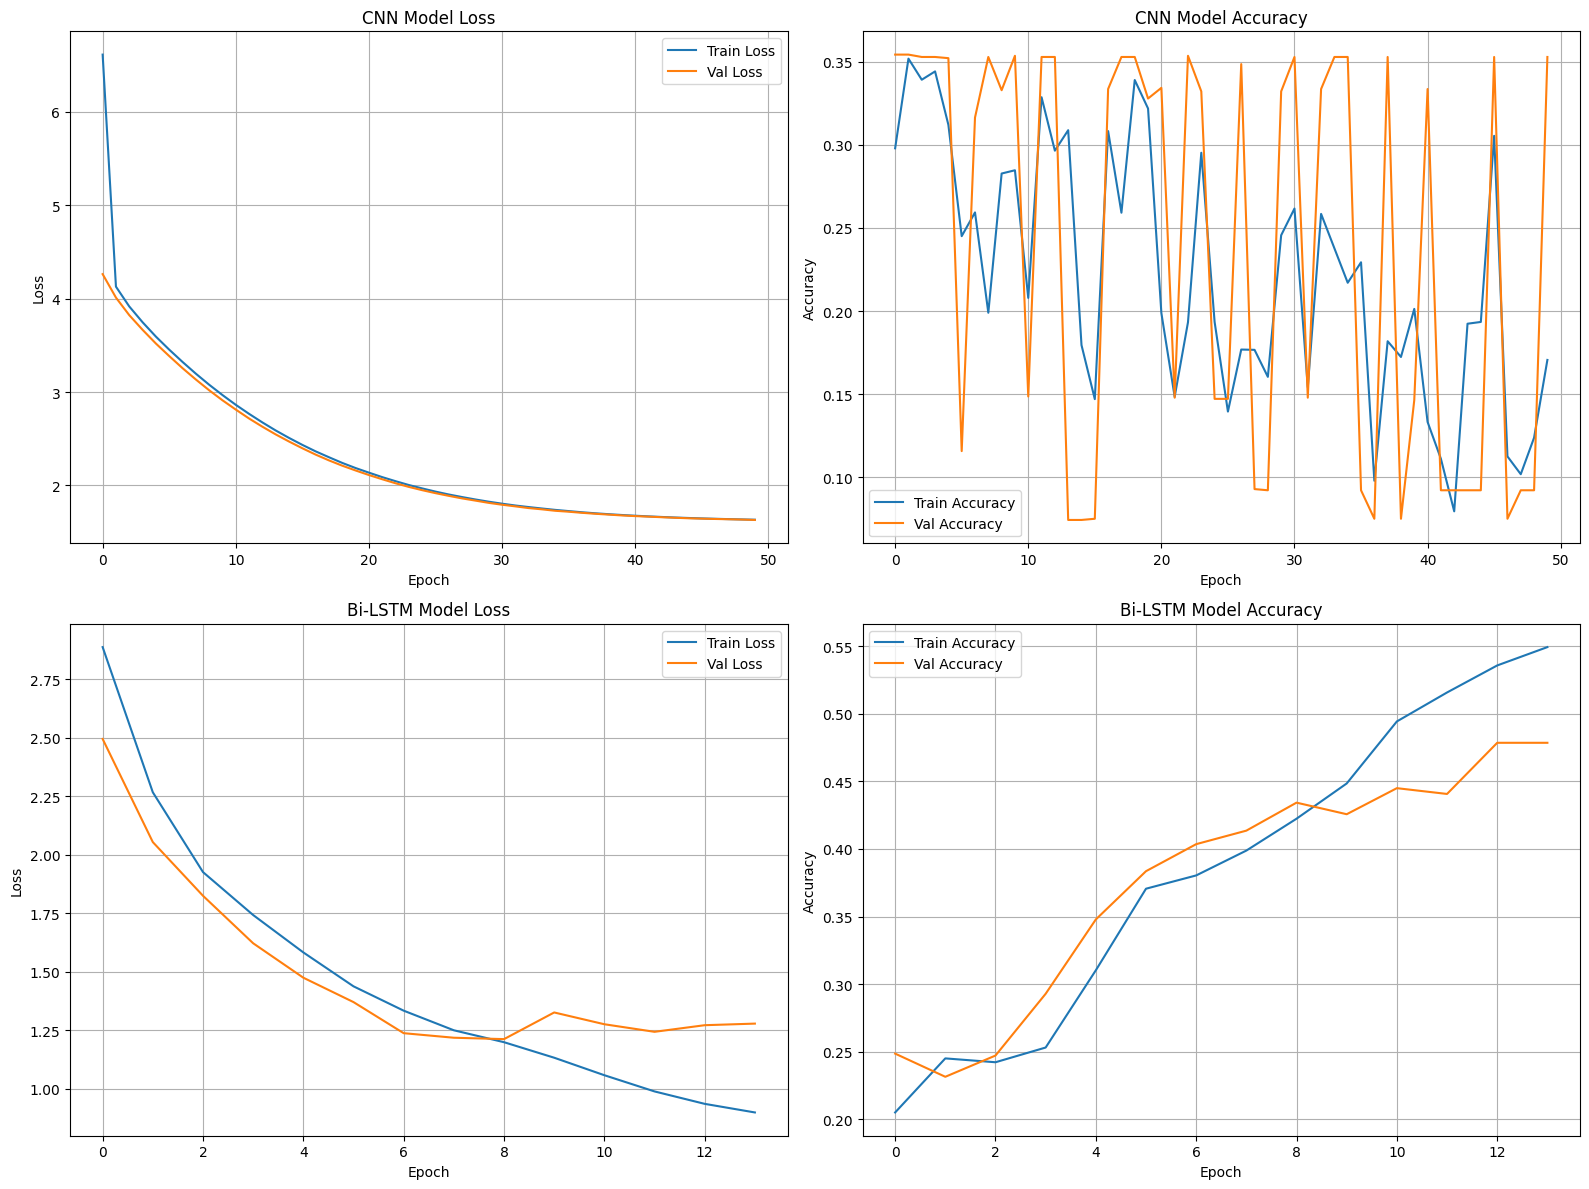

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# CNN Loss
axes[0, 0].plot(cnn_history.history['loss'], label='Train Loss')
axes[0, 0].plot(cnn_history.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('CNN Model Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# CNN Accuracy
axes[0, 1].plot(cnn_history.history['accuracy'], label='Train Accuracy')
axes[0, 1].plot(cnn_history.history['val_accuracy'], label='Val Accuracy')
axes[0, 1].set_title('CNN Model Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# LSTM Loss
axes[1, 0].plot(lstm_history.history['loss'], label='Train Loss')
axes[1, 0].plot(lstm_history.history['val_loss'], label='Val Loss')
axes[1, 0].set_title('Bi-LSTM Model Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True)

# LSTM Accuracy
axes[1, 1].plot(lstm_history.history['accuracy'], label='Train Accuracy')
axes[1, 1].plot(lstm_history.history['val_accuracy'], label='Val Accuracy')
axes[1, 1].set_title('Bi-LSTM Model Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()


# Confusion Matrices - CNN


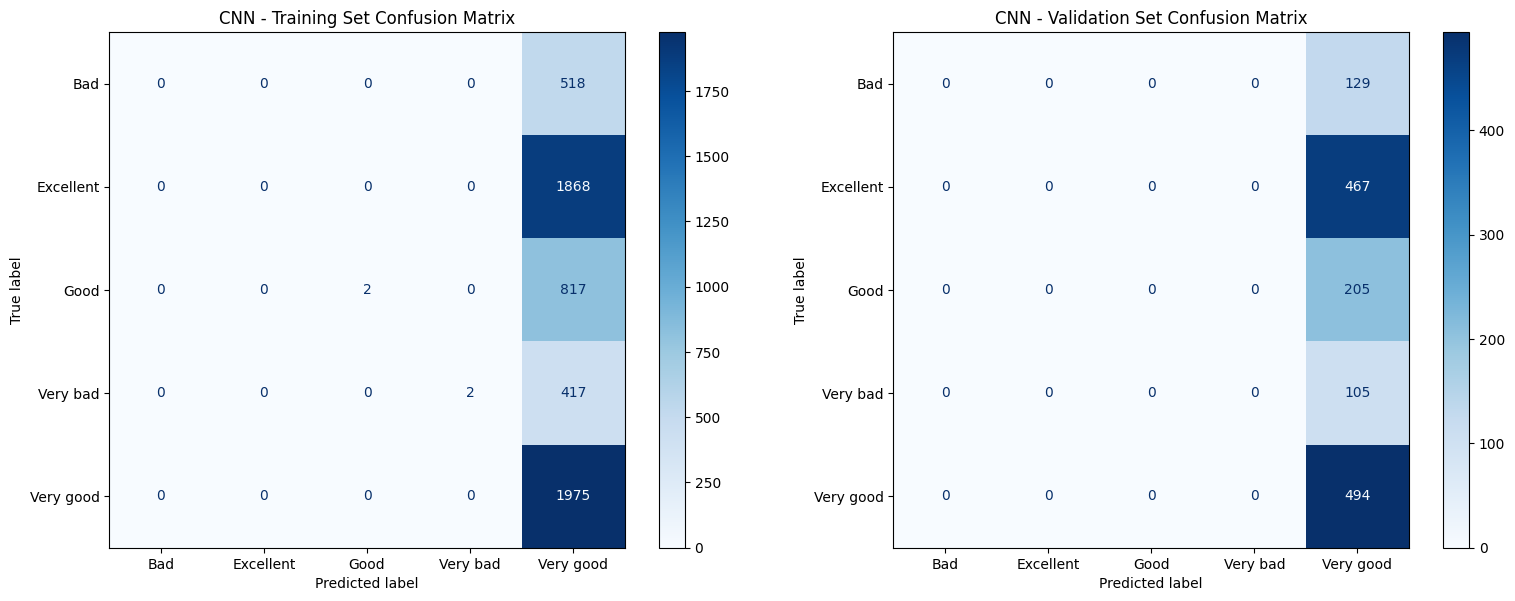

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_predictions(
    y_train_true, cnn_train_pred_classes,
    display_labels=ohe.categories_[0],
    cmap=plt.cm.Blues,
    ax=axes[0]
)
axes[0].set_title("CNN - Training Set Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_val_true, cnn_val_pred_classes,
    display_labels=ohe.categories_[0],
    cmap=plt.cm.Blues,
    ax=axes[1]
)
axes[1].set_title("CNN - Validation Set Confusion Matrix")
plt.tight_layout()
plt.show()

# Confusion Matrices - LSTM


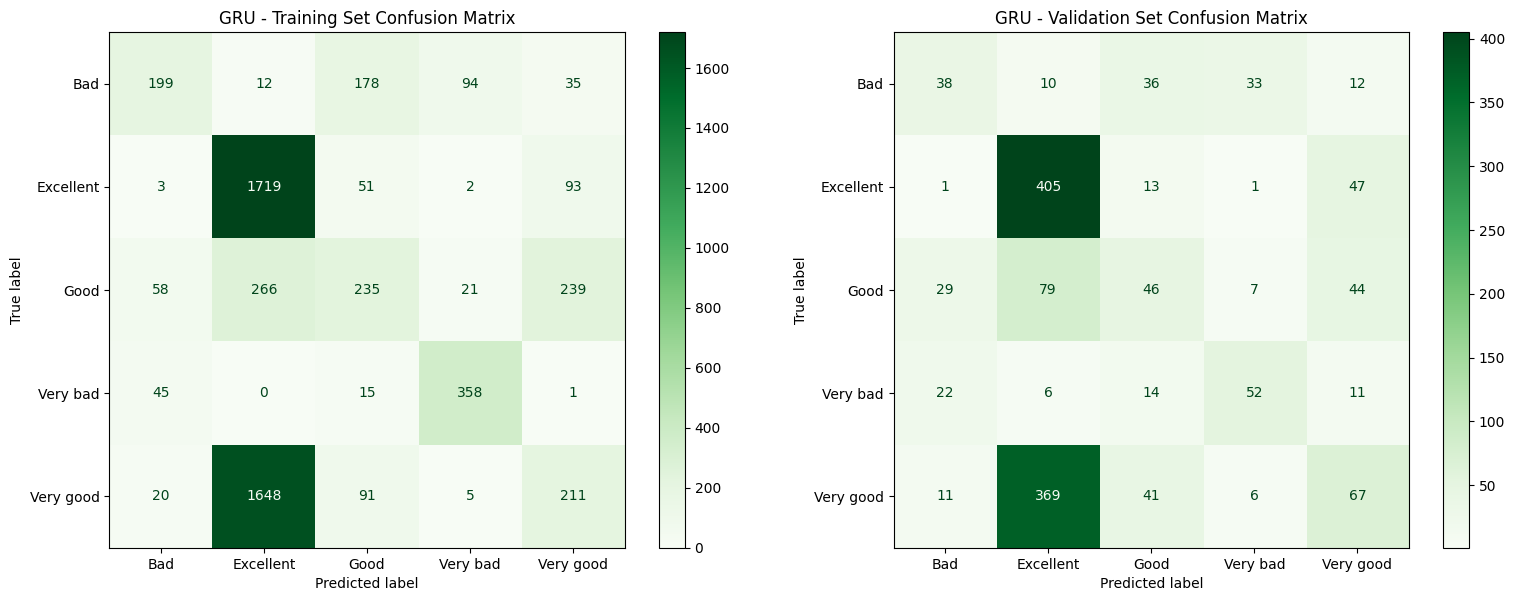

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_predictions(
    y_train_true, lstm_train_pred_classes,
    display_labels=ohe.categories_[0],
    cmap=plt.cm.Greens,
    ax=axes[0]
)
axes[0].set_title("GRU - Training Set Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_val_true, lstm_val_pred_classes,
    display_labels=ohe.categories_[0],
    cmap=plt.cm.Greens,
    ax=axes[1]
)
axes[1].set_title("GRU - Validation Set Confusion Matrix")
plt.tight_layout()
plt.show()

# testing

In [35]:

cnn_val_acc = max(cnn_history.history['val_accuracy'])
lstm_val_acc = max(lstm_history.history['val_accuracy'])

print(f"CNN Val Accuracy: {cnn_val_acc:.4f}")
print(f"GRU Val Accuracy: {lstm_val_acc:.4f}")

best_model = cnn_model if cnn_val_acc > lstm_val_acc else lstm_model
best_model_name = "CNN" if cnn_val_acc > lstm_val_acc else "GRU"

print(f"Using {best_model_name} model for predictions")


test_df = pd.read_csv("/kaggle/input/nn-26-review-sentiment-classification/test.csv")
test_ids = test_df['id']

test_df["text"] = test_df["text"].apply(clean_and_lemmatize)

X_test_seq = tokenizer.texts_to_sequences(test_df['text'])
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

test_predictions = best_model.predict(X_test_pad)
test_pred_classes = np.argmax(test_predictions, axis=1)

test_pred_labels = ohe.categories_[0][test_pred_classes]

submission = pd.DataFrame({
    'id': test_ids,
    'review': test_pred_labels
})

submission.to_csv('submission.csv', index=False)


CNN Val Accuracy: 0.3543
GRU Val Accuracy: 0.4786
Using GRU model for predictions
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step
